# Trabalho Computacional 02 — Atividade 01

## 1. Introdução

Nesta atividade, o modelo linear eletromecânico de um alto-falante é excitado por um arquivo de áudio. A entrada digital é convertida em uma tensão limitada a $2\,\mathrm{V}$, aplicada às equações diferenciais e analisada nos domínios do tempo e da frequência.

O objetivo é acompanhar a cadeia completa:

> áudio digital → tensão física → integração do modelo → corrente, deslocamento e aceleração → áudio de saída.

Somente o modelo linear é tratado neste notebook.

## 2. Bibliotecas

São utilizadas apenas ferramentas do ecossistema científico Python: NumPy para cálculo numérico, Matplotlib para gráficos e SciPy para WAV, interpolação e integração.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.io import wavfile

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
input_path = project_root / "data" / "TC02-in.wav"
output_dir = project_root / "outputs"
output_path = output_dir / "TC02-out1.wav"

assert input_path.exists(), f"Arquivo de entrada não encontrado: {input_path}"

## 3. Parâmetros físicos e condições iniciais

Os parâmetros são os valores fornecidos no enunciado. O estado inicial é de repouso, isto é, corrente, posição e velocidade inicialmente nulas.

In [2]:
m = 14.35e-3  # kg
b = 0.786     # kg/s
k = 1852.0    # N/m
Bl = 4.95     # N/A
L = 266e-6    # H
R = 3.3       # ohm

z0 = np.array([0.0, 0.0, 0.0])  # [i(0), x(0), v(0)]

assert all(parameter > 0 for parameter in (m, b, k, Bl, L, R))
assert z0.shape == (3,) and np.all(z0 == 0)

print(f"m = {m:.6g} kg, b = {b:.6g} kg/s, k = {k:.6g} N/m")
print(f"Bl = {Bl:.6g} N/A, L = {L:.6g} H, R = {R:.6g} ohm")

m = 0.01435 kg, b = 0.786 kg/s, k = 1852 N/m
Bl = 4.95 N/A, L = 0.000266 H, R = 3.3 ohm


## 4. Modelo linear

Adota-se a ordem de estados

$$
\mathbf{z}(t)=\begin{bmatrix}i(t)&x(t)&v(t)\end{bmatrix}^{T}.
$$

As equações governantes são

$$
\dot{i}=-\frac{R}{L}i-\frac{Bl}{L}v+\frac{u}{L},
\qquad
\dot{x}=v,
$$

$$
\dot{v}=\frac{Bl}{m}i-\frac{k}{m}x-\frac{b}{m}v.
$$

Na forma matricial, $\dot{\mathbf z}=A\mathbf z+B u(t)$.

In [3]:
A = np.array([
    [-R / L,       0.0, -Bl / L],
    [   0.0,       0.0,     1.0],
    [ Bl / m,    -k / m,  -b / m],
])
B = np.array([1.0 / L, 0.0, 0.0])

assert A.shape == (3, 3)
assert B.shape == (3,)
print("Matriz A:\n", A)
print("Vetor B:\n", B)

Matriz A:
 [[-1.24060150e+04  0.00000000e+00 -1.86090226e+04]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 3.44947735e+02 -1.29059233e+05 -5.47735192e+01]]
Vetor B:
 [3759.39849624    0.            0.        ]


## 5. Leitura e inspeção do áudio

As amostras digitais são mantidas intactas em `audio_digital`. Para $N$ amostras e taxa $f_s$, os instantes são construídos por $t_n=n/f_s$, evitando incluir artificialmente o instante $N/f_s$ na última amostra.

In [4]:
sample_rate, audio_digital = wavfile.read(input_path)

if audio_digital.ndim == 1:
    audio_digital_2d = audio_digital[:, np.newaxis]
else:
    audio_digital_2d = audio_digital

num_samples, num_channels = audio_digital_2d.shape
duration = num_samples / sample_rate
time = np.arange(num_samples, dtype=float) / sample_rate

print(f"Taxa de amostragem: {sample_rate} Hz")
print(f"Duração: {duration:.9f} s")
print(f"Amostras por canal: {num_samples}")
print(f"Número de canais: {num_channels}")
print(f"dtype original: {audio_digital.dtype}")
print(f"Amplitude digital mínima: {audio_digital.min()}")
print(f"Amplitude digital máxima: {audio_digital.max()}")

assert duration <= 10.0, f"O áudio possui {duration:.6f} s e excede o limite de 10 s."
assert num_samples > 1 and num_channels >= 1
assert time.shape == (num_samples,)
assert np.isclose(time[1] - time[0], 1.0 / sample_rate)
assert np.isclose(time[-1], (num_samples - 1) / sample_rate)

Taxa de amostragem: 44100 Hz
Duração: 9.009342404 s
Amostras por canal: 397312
Número de canais: 2
dtype original: int16
Amplitude digital mínima: -11451
Amplitude digital máxima: 15874


## 6. Conversão das amostras em tensão

As amplitudes digitais não representam volts diretamente. Seguindo a estratégia do professor, todos os canais são divididos pelo maior valor absoluto global e multiplicados por $2\,\mathrm{V}$. Uma única escala global preserva o balanço relativo entre os canais.

As amostras originais permanecem em `audio_digital`; a grandeza física é armazenada separadamente em `voltage`.

In [5]:
reference_amplitude = 2.0  # V
global_digital_peak = float(np.max(np.abs(audio_digital_2d.astype(np.float64))))
assert global_digital_peak > 0.0, "O arquivo de entrada é totalmente nulo."

voltage = reference_amplitude * audio_digital_2d.astype(np.float64) / global_digital_peak

assert voltage.shape == audio_digital_2d.shape
assert np.max(np.abs(voltage)) <= reference_amplitude * (1 + 1e-12)
assert np.all(np.isfinite(voltage))

print(f"Pico digital global: {global_digital_peak:.0f}")
print(f"Pico da tensão de entrada: {np.max(np.abs(voltage)):.6f} V")

Pico digital global: 15874
Pico da tensão de entrada: 2.000000 V


## 7. Entrada no domínio do tempo

O gráfico abaixo apresenta $V_{in}(t)$. Para manter a figura legível, a visualização pode reduzir apenas a quantidade de pontos desenhados; a simulação continua utilizando todas as amostras.

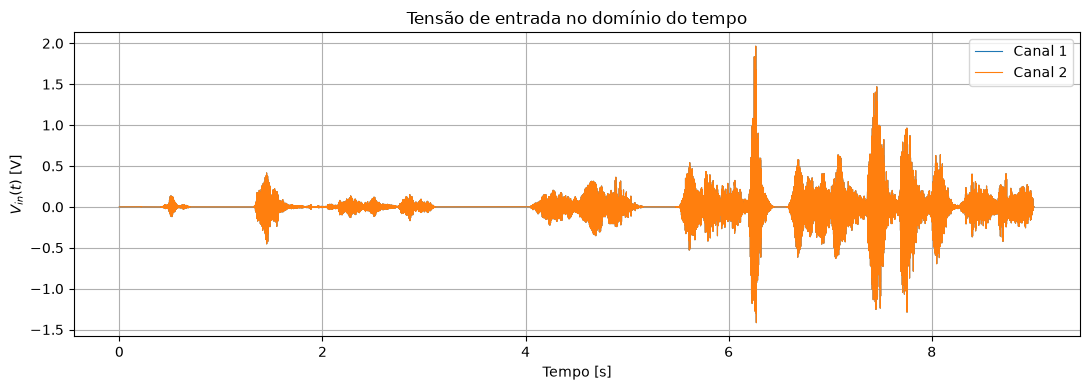

In [6]:
plot_step = max(1, num_samples // 120_000)
channel_labels = [f"Canal {channel + 1}" for channel in range(num_channels)]

for channel, label in enumerate(channel_labels):
    plt.plot(time[::plot_step], voltage[::plot_step, channel], linewidth=0.8, label=label)
plt.title("Tensão de entrada no domínio do tempo")
plt.xlabel("Tempo [s]")
plt.ylabel(r"$V_{in}(t)$ [V]")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Entrada no domínio da frequência

Para sinais reais, utiliza-se `rfft`, que retorna as frequências não negativas. A magnitude unilateral é calculada como $2|X_k|/N$, com os termos de DC e Nyquist sem duplicação. Esta escala tem unidade de volts e não é misturada com decibéis.

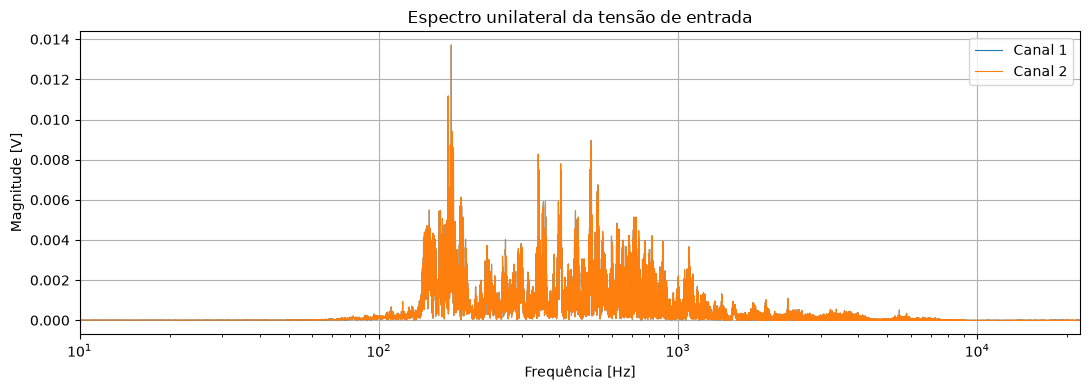

In [7]:
frequencies = np.fft.rfftfreq(num_samples, d=1.0 / sample_rate)
fft_voltage = np.fft.rfft(voltage, axis=0)
voltage_spectrum = 2.0 * np.abs(fft_voltage) / num_samples
voltage_spectrum[0, :] *= 0.5
if num_samples % 2 == 0:
    voltage_spectrum[-1, :] *= 0.5

for channel, label in enumerate(channel_labels):
    plt.semilogx(frequencies[1:], voltage_spectrum[1:, channel], linewidth=0.8, label=label)
plt.title("Espectro unilateral da tensão de entrada")
plt.xlabel("Frequência [Hz]")
plt.ylabel("Magnitude [V]")
plt.xlim(10, sample_rate / 2)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Entrada contínua para a ODE

`solve_ivp` avalia a derivada em instantes escolhidos adaptativamente, que em geral não coincidem com as amostras do WAV. Portanto, cada canal é representado por uma interpolação linear $u(t)$. Essa é a extensão contínua mais simples e coerente com os dados discretos.

In [8]:
voltage_interpolators = [
    interp1d(
        time,
        voltage[:, channel],
        kind="linear",
        bounds_error=False,
        fill_value=(voltage[0, channel], voltage[-1, channel]),
        assume_sorted=True,
    )
    for channel in range(num_channels)
]

assert all(np.isclose(interpolator(time[100]), voltage[100, channel])
           for channel, interpolator in enumerate(voltage_interpolators))

## 10. Integração do modelo linear

Cada canal é simulado efetivamente e de maneira independente. Usa-se `t_eval=time`, de modo que a solução retornada já esteja alinhada à grade do áudio. O integrador continua usando passos internos adaptativos; `t_eval` apenas especifica os instantes de saída. Assim, não é necessária uma segunda interpolação dos estados para gerar o WAV.

In [9]:
solutions = []

for channel, voltage_input in enumerate(voltage_interpolators):
    def linear_model(t, z, u=voltage_input):
        return A @ z + B * float(u(t))

    solution = solve_ivp(
        linear_model,
        t_span=(time[0], time[-1]),
        y0=z0,
        t_eval=time,
        method="RK45",
        rtol=1e-6,
        atol=np.array([1e-9, 1e-11, 1e-8]),
    )
    assert solution.success, f"Falha no canal {channel + 1}: {solution.message}"
    solutions.append(solution)
    print(f"Canal {channel + 1}: {solution.message}; {solution.nfev} avaliações da ODE")

Canal 1: The solver successfully reached the end of the integration interval.; 3885398 avaliações da ODE


Canal 2: The solver successfully reached the end of the integration interval.; 3879596 avaliações da ODE


## 11. Grandezas de saída

As linhas da solução correspondem a $i(t)$, $x(t)$ e $v(t)$. A aceleração é obtida diretamente da equação mecânica,

$$
\ddot{x}=\frac{Bl}{m}i-\frac{k}{m}x-\frac{b}{m}v,
$$

evitando amplificar ruído por diferenciação numérica.

In [10]:
states = np.stack([solution.y.T for solution in solutions], axis=2)
current = states[:, 0, :]
displacement = states[:, 1, :]
velocity = states[:, 2, :]
acceleration = (Bl / m) * current - (k / m) * displacement - (b / m) * velocity

for name, array in {
    "current": current,
    "displacement": displacement,
    "velocity": velocity,
    "acceleration": acceleration,
}.items():
    assert array.shape == (num_samples, num_channels), f"Dimensão inválida em {name}"
    assert np.all(np.isfinite(array)), f"Valores não finitos em {name}"

current_peak = float(np.max(np.abs(current)))
displacement_peak = float(np.max(np.abs(displacement)))
acceleration_peak = float(np.max(np.abs(acceleration)))

print(f"Corrente máxima em módulo: {current_peak:.9g} A")
print(f"Deslocamento máximo em módulo: {displacement_peak:.9g} m")
print(f"Aceleração máxima em módulo: {acceleration_peak:.9g} m/s²")

Corrente máxima em módulo: 0.550990855 A
Deslocamento máximo em módulo: 3.28345954e-05 m
Aceleração máxima em módulo: 191.381373 m/s²


## 12. Gráficos solicitados

Corrente, deslocamento e aceleração são apresentados nos mesmos instantes da entrada. Os canais usam a mesma escala em cada grandeza para permitir comparação direta.

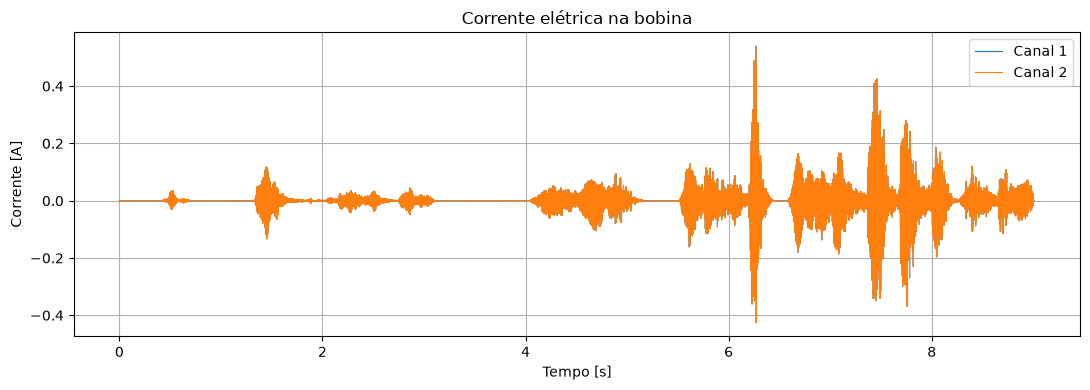

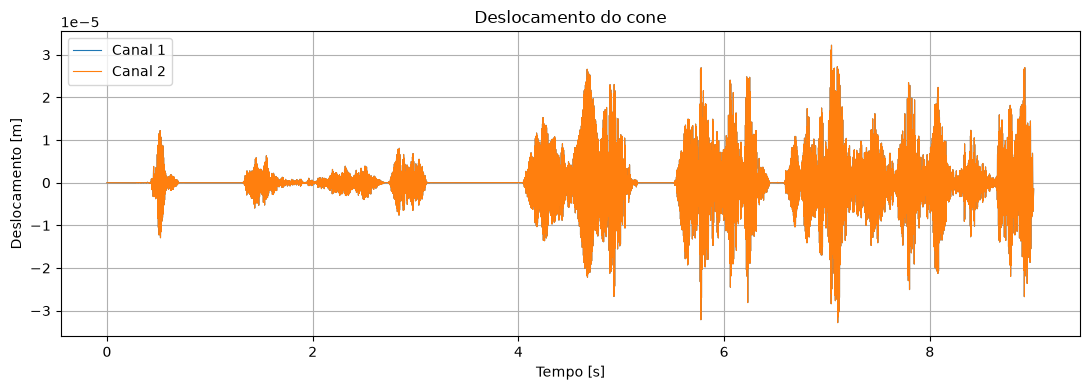

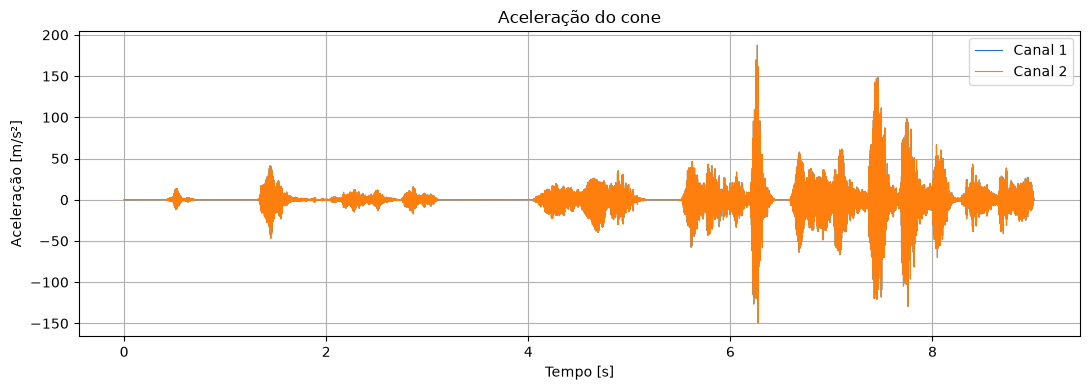

In [11]:
def plot_channels(signal, ylabel, title):
    for channel, label in enumerate(channel_labels):
        plt.plot(time[::plot_step], signal[::plot_step, channel], linewidth=0.8, label=label)
    plt.title(title)
    plt.xlabel("Tempo [s]")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_channels(current, "Corrente [A]", "Corrente elétrica na bobina")
plot_channels(displacement, "Deslocamento [m]", "Deslocamento do cone")
plot_channels(acceleration, "Aceleração [m/s²]", "Aceleração do cone")

## 13. Espectro da aceleração

A aceleração recebe sua própria transformação e sua própria escala física. O componente DC é mantido; nenhuma componente é removida silenciosamente.

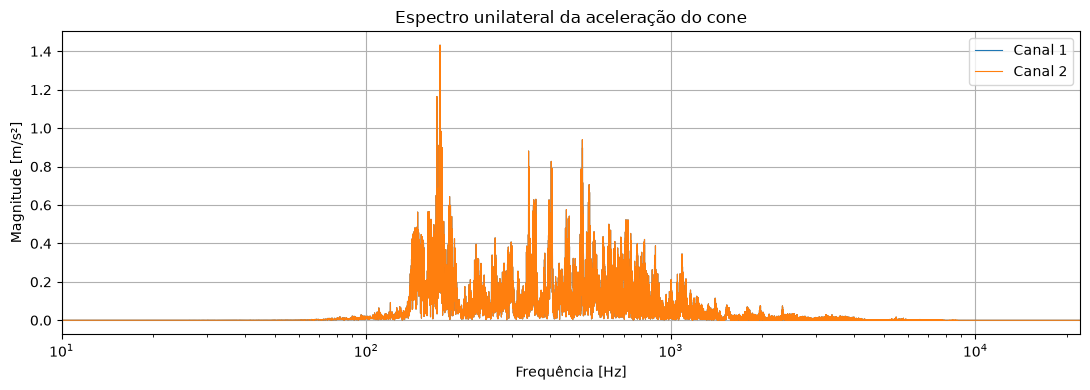

In [12]:
fft_acceleration = np.fft.rfft(acceleration, axis=0)
acceleration_spectrum = 2.0 * np.abs(fft_acceleration) / num_samples
acceleration_spectrum[0, :] *= 0.5
if num_samples % 2 == 0:
    acceleration_spectrum[-1, :] *= 0.5

for channel, label in enumerate(channel_labels):
    plt.semilogx(frequencies[1:], acceleration_spectrum[1:, channel], linewidth=0.8, label=label)
plt.title("Espectro unilateral da aceleração do cone")
plt.xlabel("Frequência [Hz]")
plt.ylabel("Magnitude [m/s²]")
plt.xlim(10, sample_rate / 2)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Comparação entre entrada e saída

Voltagem e aceleração têm unidades diferentes, portanto não são sobrepostas como se fossem a mesma grandeza. A figura usa painéis separados e magnitudes normalizadas pelo pico de cada sinal apenas para comparar a distribuição relativa do conteúdo espectral. Essa normalização é adimensional e não substitui os espectros físicos apresentados anteriormente.

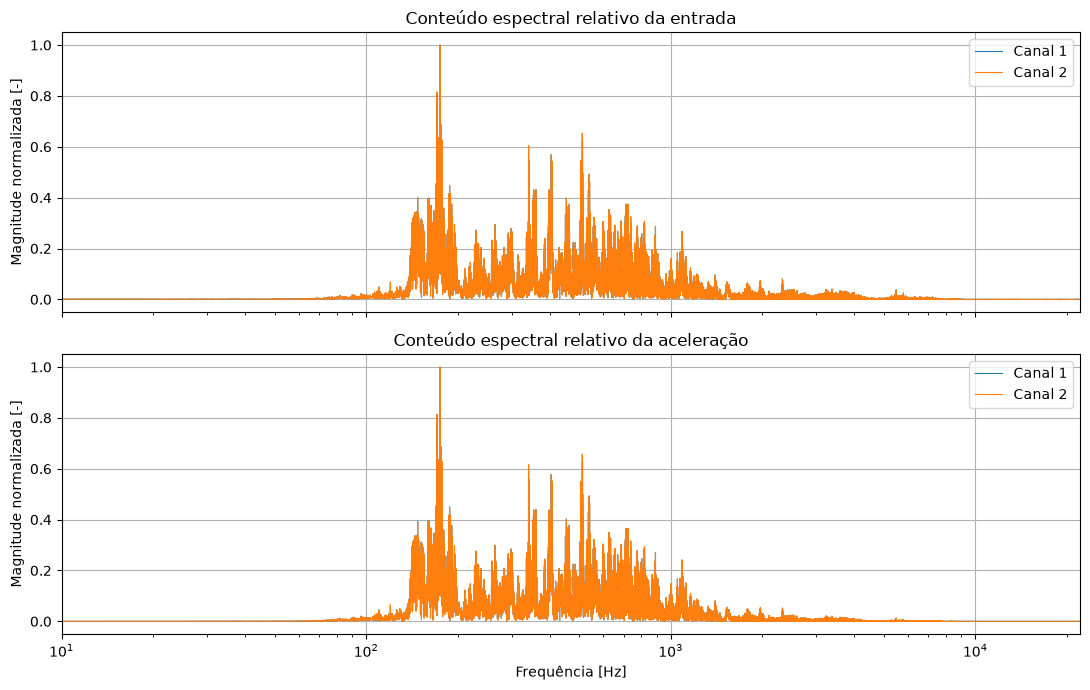

Canal 1: pico espectral de entrada em 174.71 Hz; pico da aceleração em 174.71 Hz
Canal 2: pico espectral de entrada em 174.71 Hz; pico da aceleração em 174.71 Hz


In [13]:
voltage_normalizers = np.maximum(np.max(voltage_spectrum, axis=0), np.finfo(float).eps)
acceleration_normalizers = np.maximum(np.max(acceleration_spectrum, axis=0), np.finfo(float).eps)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for channel, label in enumerate(channel_labels):
    axes[0].semilogx(frequencies[1:], voltage_spectrum[1:, channel] / voltage_normalizers[channel],
                     linewidth=0.8, label=label)
    axes[1].semilogx(frequencies[1:], acceleration_spectrum[1:, channel] / acceleration_normalizers[channel],
                     linewidth=0.8, label=label)
axes[0].set_title("Conteúdo espectral relativo da entrada")
axes[0].set_ylabel("Magnitude normalizada [-]")
axes[1].set_title("Conteúdo espectral relativo da aceleração")
axes[1].set_xlabel("Frequência [Hz]")
axes[1].set_ylabel("Magnitude normalizada [-]")
for axis in axes:
    axis.set_xlim(10, sample_rate / 2)
    axis.legend()
fig.tight_layout()
plt.show()

dominant_input = []
dominant_output = []
for channel in range(num_channels):
    input_index = 1 + int(np.argmax(voltage_spectrum[1:, channel]))
    output_index = 1 + int(np.argmax(acceleration_spectrum[1:, channel]))
    dominant_input.append(float(frequencies[input_index]))
    dominant_output.append(float(frequencies[output_index]))
    print(f"Canal {channel + 1}: pico espectral de entrada em {frequencies[input_index]:.2f} Hz; "
          f"pico da aceleração em {frequencies[output_index]:.2f} Hz")

## 15. Geração do áudio de saída

A aceleração física permanece em `acceleration`. Uma cópia é normalizada pelo máximo absoluto global para formar `audio_out_normalized`. Se a aceleração fosse nula, seria escrito um sinal nulo, evitando divisão por zero. O formato `float32` representa o WAV normalizado no intervalo $[-1,1]$.

In [14]:
output_dir.mkdir(parents=True, exist_ok=True)

output_peak = float(np.max(np.abs(acceleration)))
if output_peak > 0.0:
    audio_out_normalized = acceleration / output_peak
else:
    audio_out_normalized = np.zeros_like(acceleration)

wavfile.write(output_path, sample_rate, audio_out_normalized.astype(np.float32))
print(f"Arquivo criado: {output_path}")

Arquivo criado: /home/valentim/projects/modelagem-multifisica/Trabalho-Computacional-02/outputs/TC02-out1.wav


## 16. Verificações e interpretação

As verificações finais reabrem o arquivo exportado e conferem taxa, duração, canais, tipo, dimensões e finitude. Em seguida, os números calculados são usados para registrar uma síntese objetiva dos resultados, sem pressupor previamente o comportamento espectral.

In [15]:
output_rate, output_audio = wavfile.read(output_path)
output_samples = output_audio.shape[0]
output_channels = 1 if output_audio.ndim == 1 else output_audio.shape[1]
output_duration = output_samples / output_rate

assert output_rate == sample_rate
assert output_samples == num_samples
assert output_channels == num_channels
assert output_audio.dtype == np.float32
assert np.isclose(output_duration, duration)
assert np.all(np.isfinite(output_audio))
assert np.max(np.abs(output_audio)) <= 1.0 + 1e-6
assert not np.shares_memory(acceleration, audio_out_normalized)

print("VERIFICAÇÕES FINAIS APROVADAS")
print(f"Entrada: {sample_rate} Hz, {duration:.9f} s, {num_channels} canal(is)")
print(f"Saída:   {output_rate} Hz, {output_duration:.9f} s, {output_channels} canal(is), {output_audio.dtype}")
print(f"Picos físicos: |i|={current_peak:.9g} A, |x|={displacement_peak:.9g} m, "
      f"|a|={acceleration_peak:.9g} m/s²")
print("\nInterpretação:")
print("- A solução permaneceu finita durante toda a gravação nos dois canais.")
print("- A resposta não é uma cópia da tensão: o acoplamento elétrico e o sistema massa-mola-amortecedor "
      "modificam a amplitude relativa das componentes de frequência.")
for channel, (fin, fout) in enumerate(zip(dominant_input, dominant_output), start=1):
    relation = "coincide aproximadamente com" if np.isclose(fin, fout, atol=frequencies[1]) else "difere de"
    print(f"- No canal {channel}, o pico espectral de saída ({fout:.2f} Hz) {relation} "
          f"o pico de entrada ({fin:.2f} Hz).")
print("- O WAV exportado contém a aceleração apenas após normalização para reprodução; "
      "a variável `acceleration` conserva os valores físicos em m/s².")

VERIFICAÇÕES FINAIS APROVADAS
Entrada: 44100 Hz, 9.009342404 s, 2 canal(is)
Saída:   44100 Hz, 9.009342404 s, 2 canal(is), float32
Picos físicos: |i|=0.550990855 A, |x|=3.28345954e-05 m, |a|=191.381373 m/s²

Interpretação:
- A solução permaneceu finita durante toda a gravação nos dois canais.
- A resposta não é uma cópia da tensão: o acoplamento elétrico e o sistema massa-mola-amortecedor modificam a amplitude relativa das componentes de frequência.
- No canal 1, o pico espectral de saída (174.71 Hz) coincide aproximadamente com o pico de entrada (174.71 Hz).
- No canal 2, o pico espectral de saída (174.71 Hz) coincide aproximadamente com o pico de entrada (174.71 Hz).
- O WAV exportado contém a aceleração apenas após normalização para reprodução; a variável `acceleration` conserva os valores físicos em m/s².


# Atividade 02 — Inserindo não linearidade

## 1. Motivação física

No modelo linear, o fator de força $Bl_0$ é constante. O enunciado propõe representar a redução do acoplamento eletromecânico à medida que a bobina se afasta da posição de repouso por meio de uma função simétrica $Bl(x)$.

Nesta atividade apenas construímos e validamos essa função. Ela **ainda não é inserida nas equações diferenciais**; essa modificação pertence à Atividade 03.

## 2. Determinação da excursão máxima linear

A fonte de $x_{\max}$ é o deslocamento calculado na Atividade 01. Considerando simultaneamente todos os instantes e canais,

$$
x_{\max}=\max_{t,c}|x_c(t)|.
$$

In [16]:
x_max = float(np.max(np.abs(displacement)))

assert np.isfinite(x_max) and x_max > 0.0
assert np.isclose(x_max, displacement_peak)

print(f"x_max = {x_max:.12e} m")
print(f"x_max = {1e3 * x_max:.9f} mm")

x_max = 3.283459543022e-05 m
x_max = 0.032834595 mm


## 3. Cálculo de $x_1$ e $x_2$

Conforme o enunciado,

$$
x_1=0{,}75x_{\max},\qquad x_2=1{,}50x_{\max}.
$$

Os limites são derivados programaticamente da resposta linear, e não inseridos manualmente.

In [17]:
x1 = 0.75 * x_max
x2 = 1.50 * x_max

assert x2 > x_max > x1 > 0.0

print("Limites da não linearidade:")
print(f"x_max = {x_max:.12e} m = {1e3 * x_max:.9f} mm")
print(f"x1    = {x1:.12e} m = {1e3 * x1:.9f} mm")
print(f"x2    = {x2:.12e} m = {1e3 * x2:.9f} mm")

Limites da não linearidade:
x_max = 3.283459543022e-05 m = 0.032834595 mm
x1    = 2.462594657266e-05 m = 0.024625947 mm
x2    = 4.925189314532e-05 m = 0.049251893 mm


## 4. Construção matemática de $Bl(x)$

Definimos $r=|x|$ para garantir simetria e adotamos

$$
Bl(x)=
\begin{cases}
Bl_0, & r\le x_1,\\[4pt]
p(r), & x_1<r<x_2,\\[4pt]
0, & r\ge x_2.
\end{cases}
$$

O enunciado determina que $p$ seja quadrático e que conecte $Bl_0$ em $x_1$ a zero em $x_2$. Essas duas condições não determinam sozinhas os três coeficientes de

$$p(r)=ar^2+br+c.$$

Como **decisão adicional de modelagem autorizada**, e não como condição explicitamente fornecida pelo professor, adotamos

$$p'(x_1)=0.$$

Essa condição torna suave a passagem da região constante para a região de decaimento. As três condições são, portanto,

$$
p(x_1)=Bl_0,\qquad p'(x_1)=0,\qquad p(x_2)=0.
$$

Como $p'(r)=2ar+b$, a segunda condição fornece $b=-2ax_1$. Substituindo nas condições de valor e eliminando $c$, resulta

$$
a=-\frac{Bl_0}{(x_2-x_1)^2},\qquad
b=\frac{2Bl_0x_1}{(x_2-x_1)^2},\qquad
c=Bl_0\left[1-\frac{x_1^2}{(x_2-x_1)^2}\right].
$$

A forma deslocada, mais clara e numericamente conveniente, é

$$
\boxed{p(r)=Bl_0\left[1-\left(\frac{r-x_1}{x_2-x_1}\right)^2\right]}.
$$

Por inspeção, $p(x_1)=Bl_0$, $p'(x_1)=0$ e $p(x_2)=0$.

In [18]:
Bl0 = Bl
transition_width = x2 - x1

a_bl = -Bl0 / transition_width**2
b_bl = 2.0 * Bl0 * x1 / transition_width**2
c_bl = Bl0 * (1.0 - x1**2 / transition_width**2)

assert np.isclose(a_bl * x1**2 + b_bl * x1 + c_bl, Bl0)
assert np.isclose(2.0 * a_bl * x1 + b_bl, 0.0, atol=1e-10)
assert np.isclose(a_bl * x2**2 + b_bl * x2 + c_bl, 0.0, atol=1e-12)

print("Coeficientes de p(r) = a r² + b r + c:")
print(f"a = {a_bl:.12e} N/(A·m²)")
print(f"b = {b_bl:.12e} N/(A·m)")
print(f"c = {c_bl:.12e} N/A")

Coeficientes de p(r) = a r² + b r + c:
a = -8.162427430176e+09 N/(A·m²)
b = 4.020150035975e+05 N/(A·m)
c = 0.000000000000e+00 N/A


## 5. Implementação de $Bl(x)$

A função abaixo aceita escalares e arrays NumPy. Ela utiliza a forma deslocada na região intermediária, sem clipping, histerese ou qualquer outra não linearidade.

In [19]:
def force_factor_nonlinear(x):
    # Fator de força simétrico Bl(x), em N/A, para x dado em metros.
    x_array = np.asarray(x, dtype=float)
    r = np.abs(x_array)
    polynomial = Bl0 * (1.0 - ((r - x1) / transition_width) ** 2)
    result = np.where(r <= x1, Bl0, np.where(r < x2, polynomial, 0.0))
    return float(result) if result.ndim == 0 else result


print(f"Bl(0) = {force_factor_nonlinear(0.0):.9f} N/A")

Bl(0) = 4.950000000 N/A


## 6. Validação numérica

São verificados os valores prescritos, um ponto intermediário, pontos externos, simetria, continuidade nas quatro fronteiras e não negatividade na faixa de validação.

In [20]:
x_mid = 0.5 * (x1 + x2)
external_points = np.array([-1.10 * x2, 1.10 * x2])

assert np.isclose(force_factor_nonlinear(0.0), Bl0)
assert np.isclose(force_factor_nonlinear(x1), Bl0)
assert np.isclose(force_factor_nonlinear(-x1), Bl0)
assert np.isclose(force_factor_nonlinear(x2), 0.0, atol=1e-12)
assert np.isclose(force_factor_nonlinear(-x2), 0.0, atol=1e-12)
assert 0.0 < force_factor_nonlinear(x_mid) < Bl0
assert np.allclose(force_factor_nonlinear(external_points), 0.0, atol=1e-12)

symmetry_points = np.linspace(0.0, 1.25 * x2, 1001)
symmetry_error = float(np.max(np.abs(
    force_factor_nonlinear(symmetry_points) - force_factor_nonlinear(-symmetry_points)
)))
assert np.allclose(
    force_factor_nonlinear(symmetry_points),
    force_factor_nonlinear(-symmetry_points),
    rtol=0.0,
    atol=1e-12,
)

boundary_epsilon = 1e-9 * x2
boundaries = np.array([-x2, -x1, x1, x2])
continuity_jumps = np.abs(
    force_factor_nonlinear(boundaries + boundary_epsilon)
    - force_factor_nonlinear(boundaries - boundary_epsilon)
)
max_continuity_jump = float(np.max(continuity_jumps))
assert max_continuity_jump < 1e-7

validation_x = np.linspace(-1.25 * x2, 1.25 * x2, 5001)
validation_bl = force_factor_nonlinear(validation_x)
assert np.all(np.isfinite(validation_bl))
assert np.min(validation_bl) >= -1e-12

print("Valores obrigatórios:")
for label, point in [
    ("0", 0.0), ("x1", x1), ("-x1", -x1),
    ("x_mid", x_mid), ("x2", x2), ("-x2", -x2),
    ("1.10*x2", 1.10 * x2),
]:
    print(f"Bl({label:>7}) = {force_factor_nonlinear(point):.12g} N/A")

print(f"Erro máximo de simetria: {symmetry_error:.3e} N/A")
print(f"Maior diferença ao redor das fronteiras: {max_continuity_jump:.3e} N/A")
print(f"Mínimo na faixa de validação: {np.min(validation_bl):.12g} N/A")
print("VALIDAÇÕES DE Bl(x) APROVADAS")

Valores obrigatórios:
Bl(      0) = 4.95 N/A
Bl(     x1) = 4.95 N/A
Bl(    -x1) = 4.95 N/A
Bl(  x_mid) = 3.7125 N/A
Bl(     x2) = 0 N/A
Bl(    -x2) = 0 N/A
Bl(1.10*x2) = 0 N/A
Erro máximo de simetria: 0.000e+00 N/A
Maior diferença ao redor das fronteiras: 1.980e-08 N/A
Mínimo na faixa de validação: 0 N/A
VALIDAÇÕES DE Bl(x) APROVADAS


## 7. Visualização de $Bl(x)$

O eixo horizontal é apresentado em milímetros. A faixa se estende além de $\pm x_2$ para tornar visíveis as regiões externas em que o fator de força é nulo.

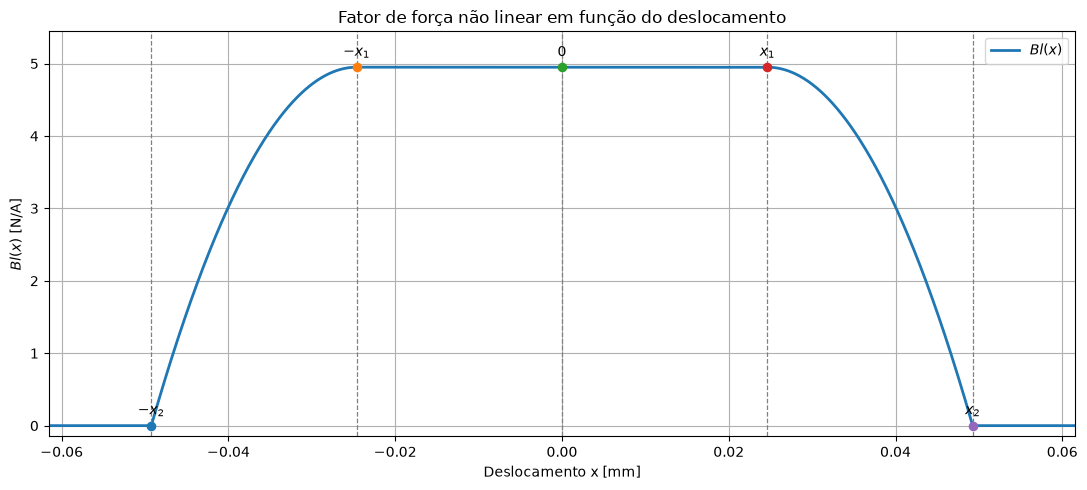

In [21]:
plot_x = np.linspace(-1.25 * x2, 1.25 * x2, 2001)
plot_bl = force_factor_nonlinear(plot_x)

plt.figure(figsize=(11, 5))
plt.plot(1e3 * plot_x, plot_bl, color="tab:blue", linewidth=2.0, label=r"$Bl(x)$")
for point, label in [(-x2, r"$-x_2$"), (-x1, r"$-x_1$"), (0.0, "0"),
                     (x1, r"$x_1$"), (x2, r"$x_2$")]:
    plt.axvline(1e3 * point, color="gray", linestyle="--", linewidth=0.9)
    plt.scatter(1e3 * point, force_factor_nonlinear(point), s=35, zorder=3)
    plt.annotate(label, (1e3 * point, force_factor_nonlinear(point)),
                 xytext=(0, 8), textcoords="offset points", ha="center")
plt.title("Fator de força não linear em função do deslocamento")
plt.xlabel("Deslocamento x [mm]")
plt.ylabel(r"$Bl(x)$ [N/A]")
plt.xlim(1e3 * plot_x[0], 1e3 * plot_x[-1])
plt.ylim(-0.15, 1.10 * Bl0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Relação com a excursão da Atividade 01

Como $x_1=0{,}75x_{\max}$, a excursão máxima do modelo linear está além do início da transição e abaixo de $x_2$. Portanto, quando essa função for incorporada futuramente ao modelo, os maiores deslocamentos lineares estarão na região em que o fator de força já diminui. Esta observação apenas antecipa qualitativamente uma possível diferença; nenhuma simulação não linear é feita aqui.

In [22]:
Bl_at_xmax = force_factor_nonlinear(x_max)
relative_Bl_at_xmax = Bl_at_xmax / Bl0

assert x1 < x_max < x2
assert 0.0 < Bl_at_xmax < Bl0

print(f"x1 < x_max < x2: {x1 < x_max < x2}")
print(f"Bl(x_max) = {Bl_at_xmax:.9f} N/A")
print(f"Bl0       = {Bl0:.9f} N/A")
print(f"Bl(x_max)/Bl0 = {relative_Bl_at_xmax:.6f}")
print("A excursão linear máxima pertence à região de decaimento polinomial.")

x1 < x_max < x2: True
Bl(x_max) = 4.400000000 N/A
Bl0       = 4.950000000 N/A
Bl(x_max)/Bl0 = 0.888889
A excursão linear máxima pertence à região de decaimento polinomial.
